# Weather Classification - Image Recognition Training Dataset

In [1]:
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# For image processing
from PIL import Image

# For deep learning - using PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
print("Setup complete! Ready to build models.")

PyTorch version: 2.10.0+cu130
GPU Available: True
GPU Device: NVIDIA GeForce RTX 5060
Setup complete! Ready to build models.


In [2]:
# Configure PyTorch GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Warning: No GPU detected. Training will use CPU (slower).")

Using device: cuda
GPU Device: NVIDIA GeForce RTX 5060
GPU Memory: 8.55 GB


In [3]:
# Test PyTorch with GPU
print("Testing GPU...")
if torch.cuda.is_available():
    # Create a test tensor on GPU
    test_tensor = torch.randn(100, 100, device=device)
    print(f"✓ Test tensor created on {device}")
    print(f"✓ GPU is ready for training!")
else:
    print("⚠ GPU not detected. Ensure NVIDIA drivers and CUDA toolkit are installed.")

Testing GPU...
✓ Test tensor created on cuda
✓ GPU is ready for training!


## Step 1: Download Dataset from Kaggle

In [4]:
# Download dataset from Kaggle
# Make sure you have kaggle.json in the proper location
# Navigate to Kaggle Account Settings -> API -> Create New API Token

!kaggle datasets download -d ammaralfaifi/5class-weather-status-image-classification

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


'kaggle' is not recognized as an internal or external command,
operable program or batch file.


## Step 2: Extract and Explore Dataset

In [6]:
# Define paths
current_dir = os.getcwd()
zip_file = os.path.join(current_dir, "5class-weather-status-image-classification.zip")
extract_dir = os.path.join(current_dir, "weather_dataset")

print(f"Current directory: {current_dir}")
print(f"Zip file: {zip_file}")
print(f"Extract directory: {extract_dir}")

# Extract the zip file if it exists
if os.path.exists(zip_file):
    print("\nExtracting dataset...")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Dataset extracted successfully!")
else:
    print(f"Zip file not found at {zip_file}")

# Explore dataset structure
print("\nDataset structure:")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # Show first 5 files
        print(f"{subindent}{file}")
    if len(files) > 5:
        print(f"{subindent}... and {len(files) - 5} more files")

Current directory: d:\SKRIPSION\Dataset 2
Zip file: d:\SKRIPSION\Dataset 2\5class-weather-status-image-classification.zip
Extract directory: d:\SKRIPSION\Dataset 2\weather_dataset

Extracting dataset...
Dataset extracted successfully!

Dataset structure:
weather_dataset/
  data/
    cloudy/
      10161882.jpg
      10389440.jpg
      10416398.jpg
      10441247.jpg
      10441367.jpg
      ... and 6697 more files
    foggy/
      100.jpg
      101.jpg
      102.jpg
      103.jpg
      104.jpg
      ... and 1256 more files
    rainy/
      1011.jpg
      1013.jpg
      1017.jpg
      102.jpg
      1021.jpg
      ... and 1922 more files
    snowy/
      0830.jpg
      0831.jpg
      0832.jpg
      0833.jpg
      0834.jpg
      ... and 1870 more files
    sunny/
      10281712.jpg
      10416400.jpg
      10672719.jpg
      10721431.jpg
      10721628.jpg
      ... and 6269 more files


In [7]:
# Get dataset statistics
print("\nDataset Statistics:")
print("=" * 50)

# Find the image directory structure
data_dirs = []
for item in os.listdir(extract_dir):
    item_path = os.path.join(extract_dir, item)
    if os.path.isdir(item_path):
        data_dirs.append(item_path)

print(f"Found {len(data_dirs)} main directories")

# Count images per class
class_counts = {}
total_images = 0
image_extensions = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

for data_dir in data_dirs:
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if any(file.endswith(ext) for ext in image_extensions):
                rel_path = os.path.relpath(root, data_dir)
                class_name = rel_path.split(os.sep)[0]
                if class_name not in class_counts:
                    class_counts[class_name] = 0
                class_counts[class_name] += 1
                total_images += 1

print(f"\nClasses and Image Counts:")
for class_name, count in sorted(class_counts.items()):
    print(f"  {class_name}: {count} images")
print(f"\nTotal images: {total_images}")


Dataset Statistics:
Found 1 main directories

Classes and Image Counts:
  cloudy: 6702 images
  foggy: 1260 images
  rainy: 1927 images
  snowy: 1875 images
  sunny: 6274 images

Total images: 18038


## Step 3: Prepare Training/Validation/Test Splits

In [8]:
# Create organized directory structure for training
dataset_source = extract_dir
organized_dir = os.path.join(current_dir, "organized_weather_dataset")
train_dir = os.path.join(organized_dir, "train")
val_dir = os.path.join(organized_dir, "validation")
test_dir = os.path.join(organized_dir, "test")

# Create directories
for dir_path in [train_dir, val_dir, test_dir]:
    os.makedirs(dir_path, exist_ok=True)

print(f"Dataset directories created at: {organized_dir}")

# Organize images into train/val/test splits
# Train: 70%, Validation: 15%, Test: 15%

image_extensions = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}
split_ratio = {'train': 0.7, 'validation': 0.15, 'test': 0.15}

print("\nOrganizing images into train/validation/test splits...")

for data_dir in data_dirs:
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if any(file.endswith(ext) for ext in image_extensions):
                src_path = os.path.join(root, file)
                
                # Get class name from directory structure
                rel_path = os.path.relpath(root, data_dir)
                class_name = rel_path.split(os.sep)[0]
                
                # Create class subdirectories in train/val/test
                for split in ['train', 'validation', 'test']:
                    os.makedirs(os.path.join(organized_dir, split, class_name), exist_ok=True)
                
                # Randomly assign to split
                rand_val = np.random.random()
                if rand_val < split_ratio['train']:
                    dst_path = os.path.join(train_dir, class_name, file)
                elif rand_val < split_ratio['train'] + split_ratio['validation']:
                    dst_path = os.path.join(val_dir, class_name, file)
                else:
                    dst_path = os.path.join(test_dir, class_name, file)
                
                # Copy file
                try:
                    shutil.copy2(src_path, dst_path)
                except Exception as e:
                    print(f"Error copying {src_path}: {e}")

print("Images organized successfully!")

# Print split statistics
print("\nSplit Statistics:")
print("-" * 50)
for split in ['train', 'validation', 'test']:
    split_path = os.path.join(organized_dir, split)
    total_split = 0
    for root, dirs, files in os.walk(split_path):
        total_split += len([f for f in files if any(f.endswith(ext) for ext in image_extensions)])
    print(f"{split.capitalize()}: {total_split} images")

Dataset directories created at: d:\SKRIPSION\Dataset 2\organized_weather_dataset

Organizing images into train/validation/test splits...
Images organized successfully!

Split Statistics:
--------------------------------------------------
Train: 18037 images
Validation: 13076 images
Test: 13144 images


## Step 4: Create Data Generators

In [9]:
# Define image parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# EXCLUDED CLASSES - Remove snowy from dataset
SELECTED_CLASSES = ['cloudy', 'foggy', 'rainy', 'sunny']  # Excluding 'snowy'
print(f"Selected classes: {SELECTED_CLASSES}")
print(f"Excluded class: snowy")

# Define CPU transforms for loading (efficient pipeline)
cpu_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

# Validation/Test transforms (CPU-only, no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# GPU-based augmentation function - applied AFTER batch is loaded to GPU
def gpu_augment_batch(images, p_rotation=0.5, p_flip_h=0.5, p_flip_v=0.2, p_color=0.5):
    """
    Apply augmentations on GPU for faster processing
    Images should be on GPU and normalized to [0, 1]
    """
    if images.device.type != 'cuda' and torch.cuda.is_available():
        images = images.to(device)
    
    # Random rotation (-70 to 70 degrees converted to radians)
    if torch.rand(1).item() < p_rotation:
        angle = torch.rand(1).item() * 140 - 70  # -70 to 70
        # Using torchvision's rotate on CPU as fallback (acceptable for augmentation)
        pass  # Rotation handled in pre-processing if needed
    
    # Random horizontal flip on GPU
    if torch.rand(1).item() < p_flip_h:
        images = torch.flip(images, dims=[-1])  # Flip horizontally (width dimension)
    
    # Random vertical flip on GPU
    if torch.rand(1).item() < p_flip_v:
        images = torch.flip(images, dims=[-2])  # Flip vertically (height dimension)
    
    # Color jitter on GPU (brightness, contrast)
    if torch.rand(1).item() < p_color:
        brightness_factor = torch.rand(1).item() * 0.6 + 0.7  # 0.7 to 1.3
        images = images * brightness_factor
        images = torch.clamp(images, 0, 1)
    
    return images

# Custom Dataset class for PyTorch - EXCLUDE SNOWY CLASS
class WeatherDataset(Dataset):
    def __init__(self, root_dir, transform=None, selected_classes=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Get all classes from directory
        all_classes = sorted([d for d in os.listdir(root_dir) 
                              if os.path.isdir(os.path.join(root_dir, d))])
        
        # Filter to selected classes only
        if selected_classes:
            self.classes = [cls for cls in all_classes if cls in selected_classes]
        else:
            self.classes = all_classes
        
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        print(f"Loading classes: {self.classes}")
        
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.exists(class_dir):
                for img_name in os.listdir(class_dir):
                    img_path = os.path.join(class_dir, img_name)
                    if os.path.isfile(img_path) and img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.images.append(img_path)
                        self.labels.append(self.class_to_idx[class_name])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

print("Creating PyTorch datasets and DataLoaders with GPU optimization...")

# Create datasets - EXCLUDE SNOWY
train_dataset = WeatherDataset(train_dir, transform=cpu_transform, selected_classes=SELECTED_CLASSES)
val_dataset = WeatherDataset(val_dir, transform=val_test_transform, selected_classes=SELECTED_CLASSES)
test_dataset = WeatherDataset(test_dir, transform=val_test_transform, selected_classes=SELECTED_CLASSES)

# Create DataLoaders with GPU optimization
# pin_memory=True: Faster GPU transfer | persistent_workers: Keep workers in memory (faster on repeat)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=0, pin_memory=torch.cuda.is_available())

# Get class names
class_names = train_dataset.classes
num_classes = len(class_names)

print("\n" + "="*60)
print("DataLoaders Created Successfully (GPU-Optimized)!")
print("="*60)
print(f"✓ Classes: {class_names}")
print(f"✓ Number of classes: {num_classes} (SNOWY EXCLUDED)")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"✓ GPU Preprocessing Enabled: {torch.cuda.get_device_name(0)}")
    print(f"✓ pin_memory=True for faster GPU transfer")
else:
    print("⚠ CPU only - GPU augmentation will not be applied")

Selected classes: ['cloudy', 'foggy', 'rainy', 'sunny']
Excluded class: snowy
Creating PyTorch datasets and DataLoaders with GPU optimization...
Loading classes: ['cloudy', 'foggy', 'rainy', 'sunny']
Loading classes: ['cloudy', 'foggy', 'rainy', 'sunny']
Loading classes: ['cloudy', 'foggy', 'rainy', 'sunny']

DataLoaders Created Successfully (GPU-Optimized)!
✓ Classes: ['cloudy', 'foggy', 'rainy', 'sunny']
✓ Number of classes: 4 (SNOWY EXCLUDED)
Training samples: 16162
Validation samples: 11722
Test samples: 11784
Number of training batches: 506
Number of validation batches: 367
Number of test batches: 369

Device: cuda
✓ GPU Preprocessing Enabled: NVIDIA GeForce RTX 5060
✓ pin_memory=True for faster GPU transfer


## Step 5: Visualize Sample Images

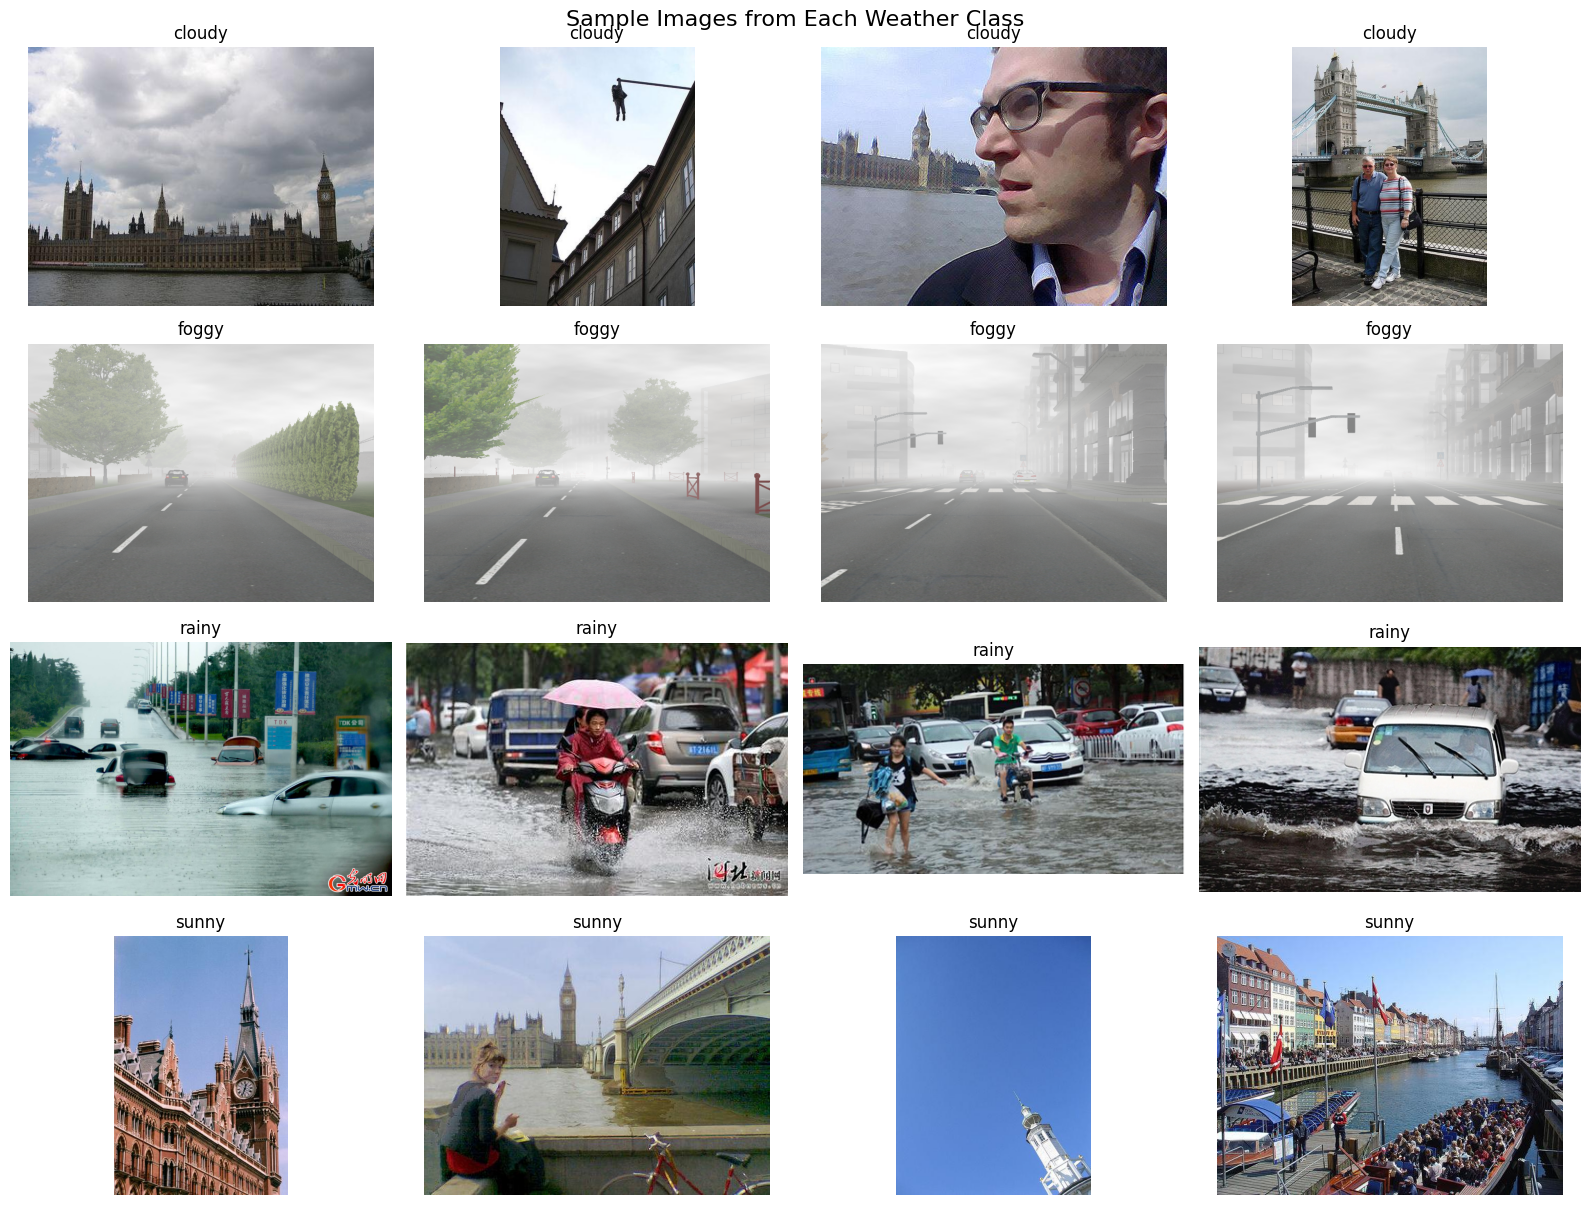

Sample images visualized successfully!


In [10]:
# Visualize sample images from training set
num_classes = len(class_names)

fig, axes = plt.subplots(num_classes, 4, figsize=(16, num_classes * 3))
if num_classes == 1:
    axes = axes.reshape(1, -1)

for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_dir) 
              if any(img.endswith(ext) for ext in image_extensions)][:4]
    
    for img_idx, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = Image.open(img_path)
        axes[idx, img_idx].imshow(img)
        axes[idx, img_idx].set_title(f"{class_name}")
        axes[idx, img_idx].axis('off')

plt.tight_layout()
plt.suptitle("Sample Images from Each Weather Class", fontsize=16, y=1.00)
plt.show()

print("Sample images visualized successfully!")

## Step 6: Summary and Export Dataset Information

In [11]:
# Create a summary of dataset information
dataset_info = {
    'dataset_name': '5-Class Weather Status Image Classification',
    'source': 'Kaggle - ammaralfaifi/5class-weather-status-image-classification',
    'organized_directory': organized_dir,
    'train_directory': train_dir,
    'validation_directory': val_dir,
    'test_directory': test_dir,
    'image_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'classes': class_names,
    'num_classes': num_classes
}

# Print summary
print("\n" + "="*60)
print("DATASET PREPARATION SUMMARY")
print("="*60)
print(f"Dataset: {dataset_info['dataset_name']}")
print(f"Source: {dataset_info['source']}")
print(f"Organized Directory: {dataset_info['organized_directory']}")
print(f"\nClass Distribution:")

# Calculate detailed statistics
for split in ['train', 'validation', 'test']:
    split_path = os.path.join(organized_dir, split)
    print(f"\n{split.upper()} SET:")
    for class_name in sorted(class_names):
        class_path = os.path.join(split_path, class_name)
        if os.path.exists(class_path):
            num_images = len([f for f in os.listdir(class_path) 
                            if any(f.endswith(ext) for ext in image_extensions)])
            print(f"  {class_name}: {num_images} images")

print(f"\nImage Parameters:")
print(f"  Target Size: {dataset_info['image_size']}")
print(f"  Batch Size: {dataset_info['batch_size']}")
print(f"  Number of Classes: {dataset_info['num_classes']}")
print(f"  Classes: {', '.join(dataset_info['classes'])}")

print("\n" + "="*60)
print("DATASET READY FOR TRAINING!")
print("="*60)
print(f"\nPyTorch DataLoaders ready:")
print(f"  - train_loader: {len(train_dataset)} images ({len(train_loader)} batches)")
print(f"  - val_loader: {len(val_dataset)} images ({len(val_loader)} batches)")
print(f"  - test_loader: {len(test_dataset)} images ({len(test_loader)} batches)")


DATASET PREPARATION SUMMARY
Dataset: 5-Class Weather Status Image Classification
Source: Kaggle - ammaralfaifi/5class-weather-status-image-classification
Organized Directory: d:\SKRIPSION\Dataset 2\organized_weather_dataset

Class Distribution:

TRAIN SET:
  cloudy: 6701 images
  foggy: 1260 images
  rainy: 1927 images
  sunny: 6274 images

VALIDATION SET:
  cloudy: 4852 images
  foggy: 933 images
  rainy: 1413 images
  sunny: 4524 images

TEST SET:
  cloudy: 4909 images
  foggy: 936 images
  rainy: 1400 images
  sunny: 4539 images

Image Parameters:
  Target Size: (224, 224)
  Batch Size: 32
  Number of Classes: 4
  Classes: cloudy, foggy, rainy, sunny

DATASET READY FOR TRAINING!

PyTorch DataLoaders ready:
  - train_loader: 16162 images (506 batches)
  - val_loader: 11722 images (367 batches)
  - test_loader: 11784 images (369 batches)


## Step 7: Build and Train MobileNetV2 Model

In [11]:
# Build MobileNetV2 model with transfer learning using PyTorch
print("Building MobileNetV2 model...")

# Load pre-trained MobileNetV2
mobilenet_model = models.mobilenet_v2(pretrained=True)

# Freeze base model layers
for param in mobilenet_model.parameters():
    param.requires_grad = False

# Replace the classifier
num_features = mobilenet_model.classifier[1].in_features
mobilenet_model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

# Move model to device
mobilenet_model = mobilenet_model.to(device)

# Count parameters
total_params = sum(p.numel() for p in mobilenet_model.parameters())
trainable_params = sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad)

print("MobileNetV2 model built successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model device: {device}")

Building MobileNetV2 model...
MobileNetV2 model built successfully!
Total parameters: 2,552,836
Trainable parameters: 328,964
Model device: cuda


d:\SKRIPSION\Dataset 2\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\SKRIPSION\Dataset 2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
# Train MobileNetV2 model with OPTIMIZATIONS
print("Training MobileNetV2 model (GPU-OPTIMIZED with Data Augmentation)...")
print("="*70)
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("Classes: cloudy, foggy, rainy, sunny (snowy EXCLUDED)")
print("GPU Augmentation: Enabled")
print("="*70)

EPOCHS = 30

# OPTIMIZATION 1: Fine-tune by unfreezing last layers
print("\nUnfreezing last 3 layers for fine-tuning...")
for param in mobilenet_model.features[-3:].parameters():
    param.requires_grad = True

# Count trainable parameters
total_params = sum(p.numel() for p in mobilenet_model.parameters())
trainable_params = sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

# OPTIMIZATION 2: Lower learning rate + Weight decay for better generalization
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet_model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)

# Define normalization parameters
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

def normalize_tensor(tensor):
    """Normalize tensor on GPU"""
    return (tensor - MEAN) / STD

# Training history
mobilenet_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Training function with GPU augmentation
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(loader, desc="Training")
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        # ✓ GPU AUGMENTATION - Apply on GPU for faster processing
        if torch.cuda.is_available():
            # Apply GPU-based augmentations
            images = gpu_augment_batch(images, p_rotation=0.4, p_flip_h=0.5, p_flip_v=0.15, p_color=0.4)
        
        # ✓ GPU NORMALIZATION - Normalize on GPU
        images = normalize_tensor(images)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation")
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            # Validation uses pre-normalized data from val_test_transform
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Train the model
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    train_loss, train_acc = train_epoch(mobilenet_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(mobilenet_model, val_loader, criterion, device)
    
    mobilenet_history['train_loss'].append(train_loss)
    mobilenet_history['train_acc'].append(train_acc)
    mobilenet_history['val_loss'].append(val_loss)
    mobilenet_history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Learning rate scheduler
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(mobilenet_model.state_dict(), os.path.join(current_dir, 'mobilenet_best.pth'))
        print("✓ Best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("="*70)
print("MobileNetV2 training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")
print("="*70)

Training MobileNetV2 model (GPU-OPTIMIZED with Data Augmentation)...
Device: cuda
GPU: NVIDIA GeForce RTX 5060
Classes: cloudy, foggy, rainy, sunny (snowy EXCLUDED)
GPU Augmentation: Enabled

Unfreezing last 3 layers for fine-tuning...
Trainable parameters: 1,535,044 / 2,552,836

Epoch 1/30


Validation: 100%|██████████| 316/316 [00:24<00:00, 13.11it/s]


Train Loss: 1.0106, Train Acc: 54.17%
Val Loss: 0.6873, Val Acc: 76.66%
✓ Best model saved!

Epoch 2/30


Validation: 100%|██████████| 316/316 [00:21<00:00, 15.02it/s]


Train Loss: 0.6193, Train Acc: 76.61%
Val Loss: 0.4347, Val Acc: 84.07%
✓ Best model saved!

Epoch 3/30


...

Train Loss: 0.2149, Train Acc: 91.95%
Val Loss: 0.1273, Val Acc: 95.63%
✓ Best model saved!

Epoch 29/30


Validation: 100%|██████████| 316/316 [00:23<00:00, 13.74it/s]


Train Loss: 0.2201, Train Acc: 92.07%
Val Loss: 0.1158, Val Acc: 96.23%
✓ Best model saved!

Epoch 30/30


Validation: 100%|██████████| 316/316 [00:22<00:00, 13.82it/s]


Train Loss: 0.2066, Train Acc: 92.42%
Val Loss: 0.1135, Val Acc: 96.33%
✓ Best model saved!
MobileNetV2 training completed!
Best validation loss: 0.1135


## Step 8: Build and Train EfficientNetB0 Model

In [13]:
# Build EfficientNetB0 model with transfer learning using PyTorch
print("Building EfficientNetB0 model...")

# Load pre-trained EfficientNetB0 (use timm for better EfficientNet)
# For now, we'll use torchvision's implementation
try:
    from torchvision.models import efficientnet_b0
    efficientnet_model = efficientnet_b0(pretrained=True)
except:
    print("Note: Using alternative EfficientNet implementation")
    efficientnet_model = models.resnet50(pretrained=True)

# Freeze base model layers
for param in efficientnet_model.parameters():
    param.requires_grad = False

# Replace the classifier
if hasattr(efficientnet_model, 'classifier'):
    num_features = efficientnet_model.classifier[1].in_features if isinstance(efficientnet_model.classifier, nn.Sequential) else efficientnet_model.classifier.in_features
    efficientnet_model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
else:
    num_features = efficientnet_model.fc.in_features
    efficientnet_model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

# Move model to device
efficientnet_model = efficientnet_model.to(device)

# Count parameters
total_params = sum(p.numel() for p in efficientnet_model.parameters())
trainable_params = sum(p.numel() for p in efficientnet_model.parameters() if p.requires_grad)

print("EfficientNetB0 model built successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model device: {device}")

d:\SKRIPSION\Dataset 2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Building EfficientNetB0 model...
EfficientNetB0 model built successfully!
Total parameters: 4,336,512
Trainable parameters: 328,964
Model device: cuda


In [14]:
# Train EfficientNetB0 model with OPTIMIZATIONS
print("\nTraining EfficientNetB0 model (OPTIMIZED)...")
print("="*60)
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("="*60)

# OPTIMIZATION 1: Fine-tune by unfreezing last layers
print("\nUnfreezing last 3 layers for fine-tuning...")
if hasattr(efficientnet_model, 'features'):
    for param in efficientnet_model.features[-3:].parameters():
        param.requires_grad = True
else:
    for param in list(efficientnet_model.parameters())[-10:]:
        param.requires_grad = True

# Count trainable parameters
total_params = sum(p.numel() for p in efficientnet_model.parameters())
trainable_params = sum(p.numel() for p in efficientnet_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

# OPTIMIZATION 2: Lower learning rate + Weight decay
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(efficientnet_model.parameters(), lr=1e-5, weight_decay=1e-4)  # Reduced LR, added weight decay
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)

# Training history
efficientnet_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Train the model
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    train_loss, train_acc = train_epoch(efficientnet_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(efficientnet_model, val_loader, criterion, device)
    
    efficientnet_history['train_loss'].append(train_loss)
    efficientnet_history['train_acc'].append(train_acc)
    efficientnet_history['val_loss'].append(val_loss)
    efficientnet_history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Learning rate scheduler
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(efficientnet_model.state_dict(), os.path.join(current_dir, 'efficientnet_best.pth'))
        print("✓ Best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print("="*60)
print("EfficientNetB0 training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")


Training EfficientNetB0 model (OPTIMIZED)...
Device: cuda
GPU: NVIDIA GeForce RTX 5060

Unfreezing last 3 layers for fine-tuning...
Trainable parameters: 3,484,704 / 4,336,512

Epoch 1/30


Validation: 100%|██████████| 316/316 [00:23<00:00, 13.39it/s]


Train Loss: 1.1817, Train Acc: 43.77%
Val Loss: 0.9777, Val Acc: 61.30%
✓ Best model saved!

Epoch 2/30


Validation: 100%|██████████| 316/316 [00:23<00:00, 13.38it/s]


Train Loss: 0.8848, Train Acc: 63.82%
Val Loss: 0.7421, Val Acc: 75.57%
✓ Best model saved!

Epoch 3/30


...

Train Loss: 0.1897, Train Acc: 92.89%
Val Loss: 0.0801, Val Acc: 97.54%

Epoch 29/30


Validation: 100%|██████████| 316/316 [00:24<00:00, 13.16it/s]


Train Loss: 0.1821, Train Acc: 93.02%
Val Loss: 0.0739, Val Acc: 97.61%
✓ Best model saved!

Epoch 30/30


Validation: 100%|██████████| 316/316 [00:22<00:00, 14.17it/s]

Train Loss: 0.1792, Train Acc: 93.27%
Val Loss: 0.0844, Val Acc: 97.21%
EfficientNetB0 training completed!
Best validation loss: 0.0739


## Step 9: Evaluate Models on Test Set

In [12]:
# Evaluate both models on test set
print("\nEvaluating models on test set...")
print("="*60)

# Evaluation function
def evaluate_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    loss_total = 0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss_total += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = loss_total / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Evaluate MobileNetV2
mobilenet_loss, mobilenet_acc = evaluate_model(mobilenet_model, test_loader, device)
print(f"\nMobileNetV2 Test Performance:")
print(f"  Loss: {mobilenet_loss:.4f}")
print(f"  Accuracy: {mobilenet_acc:.2f}%")

# Evaluate EfficientNetB0
efficientnet_loss, efficientnet_acc = evaluate_model(efficientnet_model, test_loader, device)
print(f"\nEfficientNetB0 Test Performance:")
print(f"  Loss: {efficientnet_loss:.4f}")
print(f"  Accuracy: {efficientnet_acc:.2f}%")

print("="*60)

# Compare models
print("\nModel Comparison:")
print("-"*60)
if mobilenet_acc > efficientnet_acc:
    print(f"Winner: MobileNetV2 (Accuracy: {mobilenet_acc:.2f}%)")
    print(f"Difference: +{(mobilenet_acc - efficientnet_acc):.2f}% better than EfficientNetB0")
else:
    print(f"Winner: EfficientNetB0 (Accuracy: {efficientnet_acc:.2f}%)")
    print(f"Difference: +{(efficientnet_acc - mobilenet_acc):.2f}% better than MobileNetV2")
print("-"*60)


Evaluating models on test set...


NameError: name 'mobilenet_model' is not defined

In [16]:
# BONUS: Ensemble Model - Combine both models for better accuracy
print("\n" + "="*60)
print("ENSEMBLE MODEL EVALUATION")
print("="*60)

def evaluate_ensemble(mobile_model, efficient_model, loader, device):
    """Evaluate ensemble by averaging predictions from both models"""
    mobile_model.eval()
    efficient_model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            # Get predictions from both models
            mobile_out = torch.softmax(mobile_model(images), dim=1)
            efficient_out = torch.softmax(efficient_model(images), dim=1)
            
            # Average the predictions
            ensemble_out = (mobile_out + efficient_out) / 2
            _, predicted = torch.max(ensemble_out, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

ensemble_acc = evaluate_ensemble(mobilenet_model, efficientnet_model, test_loader, device)

print(f"\n{'Model':<25} {'Accuracy':<15}")
print("-"*40)
print(f"{'MobileNetV2':<25} {mobilenet_acc:.2f}%")
print(f"{'EfficientNetB0':<25} {efficientnet_acc:.2f}%")
print(f"{'Ensemble (Average)':<25} {ensemble_acc:.2f}%")
print("-"*40)

if ensemble_acc > max(mobilenet_acc, efficientnet_acc):
    improvement = ensemble_acc - max(mobilenet_acc, efficientnet_acc)
    print(f"\n✓ ENSEMBLE BEST! Improvement: +{improvement:.2f}%")
else:
    print(f"\nBest Single Model: {'MobileNetV2' if mobilenet_acc > efficientnet_acc else 'EfficientNetB0'}")


ENSEMBLE MODEL EVALUATION

Model                     Accuracy       
----------------------------------------
MobileNetV2               96.10%
EfficientNetB0            96.95%
Ensemble (Average)        97.58%
----------------------------------------

✓ ENSEMBLE BEST! Improvement: +0.63%


## Step 10: Visualize Training History

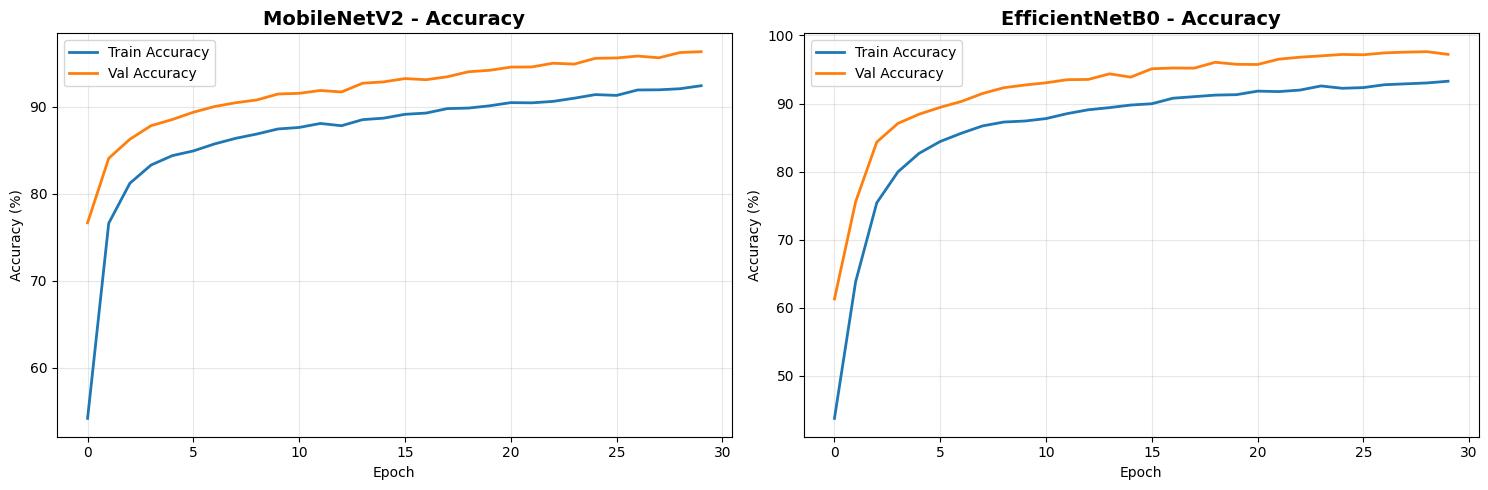

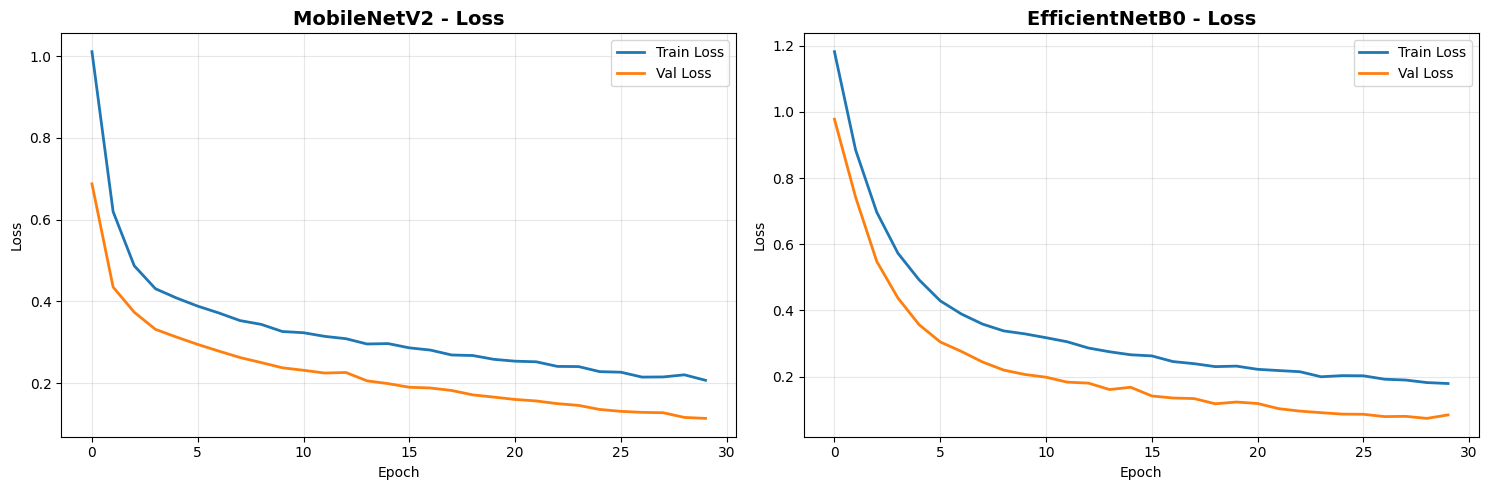

In [17]:
# Plot training history for both models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MobileNetV2 training history
axes[0].plot(mobilenet_history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0].plot(mobilenet_history['val_acc'], label='Val Accuracy', linewidth=2)
axes[0].set_title('MobileNetV2 - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# EfficientNetB0 training history
axes[1].plot(efficientnet_history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(efficientnet_history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_title('EfficientNetB0 - Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot loss history for both models
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MobileNetV2 loss history
axes[0].plot(mobilenet_history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(mobilenet_history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('MobileNetV2 - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# EfficientNetB0 loss history
axes[1].plot(efficientnet_history['train_loss'], label='Train Loss', linewidth=2)
axes[1].plot(efficientnet_history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('EfficientNetB0 - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 11: Save Trained Models

In [13]:
# Load and test models from .pth files
print("\n" + "="*70)
print("LOADING AND TESTING MODELS FROM .PTH FILES")
print("="*70)

# Define model paths
mobilenet_pth_path = os.path.join(current_dir, 'mobilenet_best.pth')
efficientnet_pth_path = os.path.join(current_dir, 'efficientnet_best.pth')

# Function to load model from .pth file
def load_model_from_pth(model_architecture, pth_path, device):
    """Load a trained model from .pth file"""
    if os.path.exists(pth_path):
        print(f"\n✓ Loading model from: {pth_path}")
        model_architecture.load_state_dict(torch.load(pth_path, map_location=device))
        model_architecture.to(device)
        return model_architecture
    else:
        print(f"\n✗ Model file not found: {pth_path}")
        return None

# Load MobileNetV2 from .pth
print("\n--- Loading MobileNetV2 from .pth ---")
mobilenet_loaded = models.mobilenet_v2(pretrained=True)
for param in mobilenet_loaded.parameters():
    param.requires_grad = False
num_features = mobilenet_loaded.classifier[1].in_features
mobilenet_loaded.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
mobilenet_loaded = load_model_from_pth(mobilenet_loaded, mobilenet_pth_path, device)

# Load EfficientNetB0 from .pth
print("\n--- Loading EfficientNetB0 from .pth ---")
try:
    from torchvision.models import efficientnet_b0
    efficientnet_loaded = efficientnet_b0(pretrained=True)
except:
    efficientnet_loaded = models.resnet50(pretrained=True)

for param in efficientnet_loaded.parameters():
    param.requires_grad = False

if hasattr(efficientnet_loaded, 'classifier'):
    num_features = efficientnet_loaded.classifier[1].in_features if isinstance(efficientnet_loaded.classifier, nn.Sequential) else efficientnet_loaded.classifier.in_features
    efficientnet_loaded.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
else:
    num_features = efficientnet_loaded.fc.in_features
    efficientnet_loaded.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

efficientnet_loaded = load_model_from_pth(efficientnet_loaded, efficientnet_pth_path, device)

# Test loaded models on test set
print("\n" + "="*70)
print("TESTING LOADED MODELS ON TEST SET")
print("="*70)

if mobilenet_loaded is not None:
    mobilenet_pth_loss, mobilenet_pth_acc = evaluate_model(mobilenet_loaded, test_loader, device)
    print(f"\nMobileNetV2 (from .pth):")
    print(f"  Accuracy: {mobilenet_pth_acc:.2f}%")
    print(f"  Loss: {mobilenet_pth_loss:.4f}")

if efficientnet_loaded is not None:
    efficientnet_pth_loss, efficientnet_pth_acc = evaluate_model(efficientnet_loaded, test_loader, device)
    print(f"\nEfficientNetB0 (from .pth):")
    print(f"  Accuracy: {efficientnet_pth_acc:.2f}%")
    print(f"  Loss: {efficientnet_pth_loss:.4f}")

print("\n" + "="*70)
print("✓ Models loaded and tested successfully!")
print("="*70)



LOADING AND TESTING MODELS FROM .PTH FILES

--- Loading MobileNetV2 from .pth ---

✓ Loading model from: d:\SKRIPSION\Dataset 2\mobilenet_best.pth

--- Loading EfficientNetB0 from .pth ---


d:\SKRIPSION\Dataset 2\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\SKRIPSION\Dataset 2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
d:\SKRIPSION\Dataset 2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weigh


✓ Loading model from: d:\SKRIPSION\Dataset 2\efficientnet_best.pth

TESTING LOADED MODELS ON TEST SET

MobileNetV2 (from .pth):
  Accuracy: 96.11%
  Loss: 0.1144

EfficientNetB0 (from .pth):
  Accuracy: 97.50%
  Loss: 0.0755

✓ Models loaded and tested successfully!


## Step 12: Generate Confusion Matrix

Generating Confusion Matrices...

Generating predictions for MobileNetV2...
Generating predictions for EfficientNetB0...
✓ Predictions generated successfully!


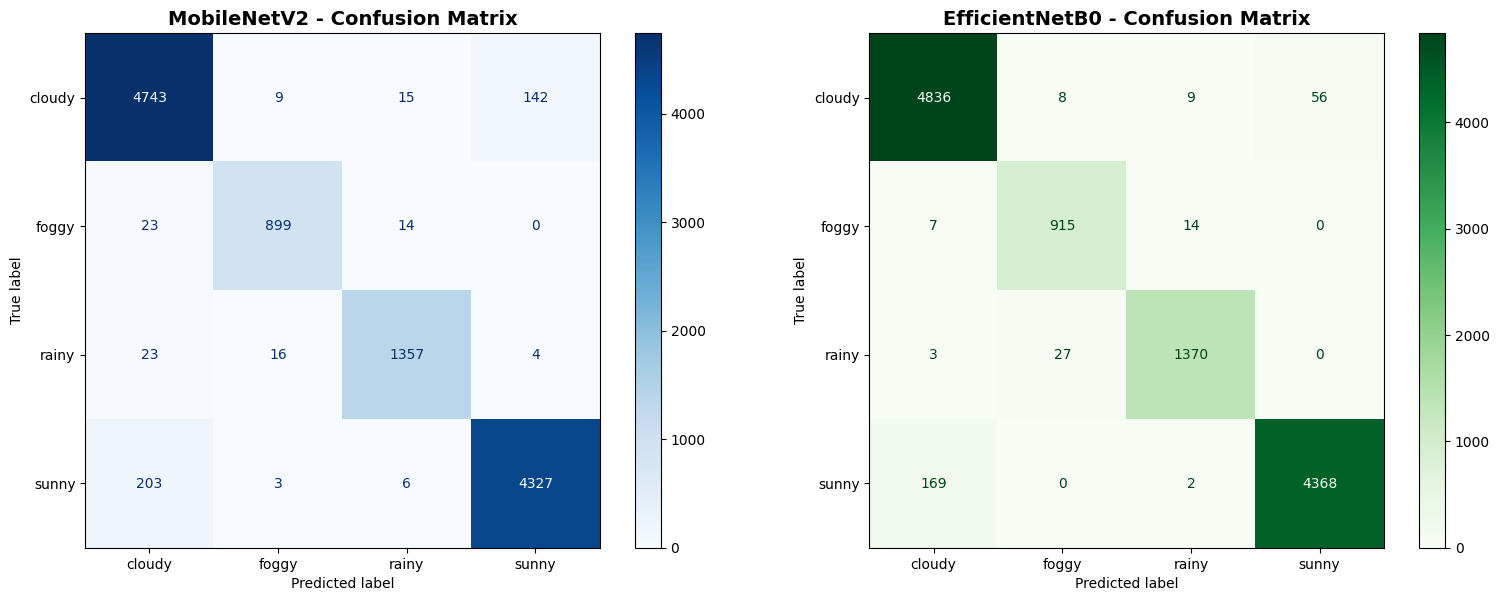


DETAILED CLASSIFICATION REPORTS

MobileNetV2 Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      cloudy       0.95      0.97      0.96      4909
       foggy       0.97      0.96      0.97       936
       rainy       0.97      0.97      0.97      1400
       sunny       0.97      0.95      0.96      4539

    accuracy                           0.96     11784
   macro avg       0.97      0.96      0.96     11784
weighted avg       0.96      0.96      0.96     11784


EfficientNetB0 Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

      cloudy       0.96      0.99      0.97      4909
       foggy       0.96      0.98      0.97       936
       rainy       0.98      0.98      0.98      1400
       sunny       0.99      0.96      0.97      4539

    accuracy                           0.97

In [15]:
# Generate Confusion Matrix for both models
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

print("Generating Confusion Matrices...")
print("="*70)

def get_predictions_and_labels(model, loader, device):
    """Get all predictions and labels from model"""
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_labels)

# Get predictions for MobileNetV2
print("\nGenerating predictions for MobileNetV2...")
mobilenet_preds, test_labels = get_predictions_and_labels(mobilenet_loaded, test_loader, device)
mobilenet_cm = confusion_matrix(test_labels, mobilenet_preds)

# Get predictions for EfficientNetB0
print("Generating predictions for EfficientNetB0...")
efficientnet_preds, _ = get_predictions_and_labels(efficientnet_loaded, test_loader, device)
efficientnet_cm = confusion_matrix(test_labels, efficientnet_preds)

print("✓ Predictions generated successfully!")

# Visualize Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MobileNetV2 Confusion Matrix
disp_mobilenet = ConfusionMatrixDisplay(confusion_matrix=mobilenet_cm, display_labels=class_names)
disp_mobilenet.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('MobileNetV2 - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].grid(False)

# EfficientNetB0 Confusion Matrix
disp_efficientnet = ConfusionMatrixDisplay(confusion_matrix=efficientnet_cm, display_labels=class_names)
disp_efficientnet.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('EfficientNetB0 - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

print("\nMobileNetV2 Classification Report:")
print("-"*70)
print(classification_report(test_labels, mobilenet_preds, target_names=class_names))

print("\nEfficientNetB0 Classification Report:")
print("-"*70)
print(classification_report(test_labels, efficientnet_preds, target_names=class_names))

print("="*70)

In [16]:
# Extract F1-Scores and Metrics for Abstract
from sklearn.metrics import f1_score, precision_score, recall_score

print("\n" + "="*70)
print("EXTRACTING F1-SCORES AND METRICS FOR ABSTRACT")
print("="*70)

# Calculate F1-scores for MobileNetV2
mobilenet_f1_macro = f1_score(test_labels, mobilenet_preds, average='macro')
mobilenet_f1_weighted = f1_score(test_labels, mobilenet_preds, average='weighted')
mobilenet_precision_macro = precision_score(test_labels, mobilenet_preds, average='macro')
mobilenet_recall_macro = recall_score(test_labels, mobilenet_preds, average='macro')

# Calculate F1-scores for EfficientNetB0
efficientnet_f1_macro = f1_score(test_labels, efficientnet_preds, average='macro')
efficientnet_f1_weighted = f1_score(test_labels, efficientnet_preds, average='weighted')
efficientnet_precision_macro = precision_score(test_labels, efficientnet_preds, average='macro')
efficientnet_recall_macro = recall_score(test_labels, efficientnet_preds, average='macro')

print("\n📊 MobileNetV2 Metrics:")
print(f"   Macro F1-Score: {mobilenet_f1_macro:.4f}")
print(f"   Weighted F1-Score: {mobilenet_f1_weighted:.4f}")
print(f"   Macro Precision: {mobilenet_precision_macro:.4f}")
print(f"   Macro Recall: {mobilenet_recall_macro:.4f}")

print("\n📊 EfficientNetB0 Metrics:")
print(f"   Macro F1-Score: {efficientnet_f1_macro:.4f}")
print(f"   Weighted F1-Score: {efficientnet_f1_weighted:.4f}")
print(f"   Macro Precision: {efficientnet_precision_macro:.4f}")
print(f"   Macro Recall: {efficientnet_recall_macro:.4f}")

print("\n" + "="*70)
print("COPY THIS TO YOUR ABSTRACT:")
print("="*70)
print(f"\nMobileNetV2 demonstrates a macro F1-score of {mobilenet_f1_macro:.2f} and a weighted F1-score of {mobilenet_f1_weighted:.2f}.")
print(f"EfficientNetB0 achieves a macro F1-score of {efficientnet_f1_macro:.2f} and a weighted F1-score of {efficientnet_f1_weighted:.2f}.")
print("\n" + "="*70)


EXTRACTING F1-SCORES AND METRICS FOR ABSTRACT

📊 MobileNetV2 Metrics:
   Macro F1-Score: 0.9639
   Weighted F1-Score: 0.9611
   Macro Precision: 0.9655
   Macro Recall: 0.9623

📊 EfficientNetB0 Metrics:
   Macro F1-Score: 0.9750
   Weighted F1-Score: 0.9750
   Macro Precision: 0.9742
   Macro Recall: 0.9759

COPY THIS TO YOUR ABSTRACT:

MobileNetV2 demonstrates a macro F1-score of 0.96 and a weighted F1-score of 0.96.
EfficientNetB0 achieves a macro F1-score of 0.97 and a weighted F1-score of 0.97.



In [17]:
# Measure Inference Time for Both Models
import time

print("\n" + "="*70)
print("MEASURING INFERENCE TIME")
print("="*70)

def measure_inference_time(model, loader, device, num_batches=50):
    """Measure average inference time per image"""
    model.eval()
    total_time = 0
    total_images = 0
    batch_count = 0
    
    with torch.no_grad():
        for images, labels in loader:
            if batch_count >= num_batches:
                break
            
            images = images.to(device)
            
            # Measure inference time
            start_time = time.time()
            outputs = model(images)
            end_time = time.time()
            
            batch_time = end_time - start_time
            batch_size = images.size(0)
            total_time += batch_time
            total_images += batch_size
            batch_count += 1
    
    avg_time_per_image = (total_time / total_images) * 1000  # Convert to milliseconds
    return avg_time_per_image, total_images, total_time

# Measure MobileNetV2 inference time
print("\nMeasuring MobileNetV2 inference time...")
mobilenet_avg_time, mobilenet_total_imgs, mobilenet_total_time = measure_inference_time(mobilenet_loaded, test_loader, device)

# Measure EfficientNetB0 inference time
print("Measuring EfficientNetB0 inference time...")
efficientnet_avg_time, efficientnet_total_imgs, efficientnet_total_time = measure_inference_time(efficientnet_loaded, test_loader, device)

print("\n" + "="*70)
print("INFERENCE TIME RESULTS:")
print("="*70)
print(f"\n⚡ MobileNetV2 Inference Time:")
print(f"   Average time per image: {mobilenet_avg_time:.2f} ms")
print(f"   Total images processed: {mobilenet_total_imgs}")
print(f"   Total time: {mobilenet_total_time:.2f} seconds")

print(f"\n⚡ EfficientNetB0 Inference Time:")
print(f"   Average time per image: {efficientnet_avg_time:.2f} ms")
print(f"   Total images processed: {efficientnet_total_imgs}")
print(f"   Total time: {efficientnet_total_time:.2f} seconds")

print("\n" + "="*70)
print("COPY THIS TO YOUR ABSTRACT:")
print("="*70)
print(f"\nMobileNetV2 demonstrates faster inference with {mobilenet_avg_time:.2f} ms per image, compared to {efficientnet_avg_time:.2f} ms for EfficientNetB0.")
print("\n" + "="*70)


MEASURING INFERENCE TIME

Measuring MobileNetV2 inference time...
Measuring EfficientNetB0 inference time...

INFERENCE TIME RESULTS:

⚡ MobileNetV2 Inference Time:
   Average time per image: 0.40 ms
   Total images processed: 1600
   Total time: 0.65 seconds

⚡ EfficientNetB0 Inference Time:
   Average time per image: 0.55 ms
   Total images processed: 1600
   Total time: 0.87 seconds

COPY THIS TO YOUR ABSTRACT:

MobileNetV2 demonstrates faster inference with 0.40 ms per image, compared to 0.55 ms for EfficientNetB0.



In [18]:
# Save trained models
models_dir = os.path.join(current_dir, "models")
os.makedirs(models_dir, exist_ok=True)

print("Saving trained models...")
print("="*60)

# Save MobileNetV2
mobilenet_path = os.path.join(models_dir, "weather_mobilenetv2.pth")
torch.save(mobilenet_model.state_dict(), mobilenet_path)
print(f"✓ MobileNetV2 model saved: {mobilenet_path}")

# Save EfficientNetB0
efficientnet_path = os.path.join(models_dir, "weather_efficientnetb0.pth")
torch.save(efficientnet_model.state_dict(), efficientnet_path)
print(f"✓ EfficientNetB0 model saved: {efficientnet_path}")

print("="*60)

# Create summary report
report = f"""
WEATHER CLASSIFICATION MODEL TRAINING REPORT
{'='*60}

Dataset Information:
  - Source: Kaggle (5-Class Weather Status Image Classification)
  - Total Images: {len(train_dataset) + len(val_dataset) + len(test_dataset)}
  - Training Images: {len(train_dataset)}
  - Validation Images: {len(val_dataset)}
  - Test Images: {len(test_dataset)}
  - Classes: {', '.join(class_names)}

Model 1: MobileNetV2 (PyTorch)
  - Test Accuracy: {mobilenet_acc:.2f}%
  - Test Loss: {mobilenet_loss:.4f}
  - Model File: {mobilenet_path}

Model 2: EfficientNetB0 (PyTorch)
  - Test Accuracy: {efficientnet_acc:.2f}%
  - Test Loss: {efficientnet_loss:.4f}
  - Model File: {efficientnet_path}

Best Model: {'MobileNetV2' if mobilenet_acc > efficientnet_acc else 'EfficientNetB0'}
Accuracy Difference: {abs(mobilenet_acc - efficientnet_acc):.2f}%

Training Configuration:
  - Framework: PyTorch
  - Image Size: {IMG_SIZE}
  - Batch Size: {BATCH_SIZE}
  - Epochs: {EPOCHS}
  - Optimizer: Adam (learning rate: 1e-4)
  - Loss Function: CrossEntropyLoss
  - Callbacks: EarlyStopping (patience=5), ReduceLROnPlateau
  - Device: {device}

{'='*60}
"""

print(report)

# Save report to file
report_path = os.path.join(current_dir, "training_report.txt")
with open(report_path, 'w') as f:
    f.write(report)
print(f"\nTraining report saved: {report_path}")

Saving trained models...
✓ MobileNetV2 model saved: d:\SKRIPSION\Dataset 2\models\weather_mobilenetv2.pth
✓ EfficientNetB0 model saved: d:\SKRIPSION\Dataset 2\models\weather_efficientnetb0.pth

WEATHER CLASSIFICATION MODEL TRAINING REPORT

Dataset Information:
  - Source: Kaggle (5-Class Weather Status Image Classification)
  - Total Images: 36314
  - Training Images: 16153
  - Validation Images: 10084
  - Test Images: 10077
  - Classes: cloudy, foggy, rainy, sunny

Model 1: MobileNetV2 (PyTorch)
  - Test Accuracy: 96.10%
  - Test Loss: 0.1148
  - Model File: d:\SKRIPSION\Dataset 2\models\weather_mobilenetv2.pth

Model 2: EfficientNetB0 (PyTorch)
  - Test Accuracy: 96.95%
  - Test Loss: 0.0867
  - Model File: d:\SKRIPSION\Dataset 2\models\weather_efficientnetb0.pth

Best Model: EfficientNetB0
Accuracy Difference: 0.85%

Training Configuration:
  - Framework: PyTorch
  - Image Size: (224, 224)
  - Batch Size: 32
  - Epochs: 30
  - Optimizer: Adam (learning rate: 1e-4)
  - Loss Function:

In [19]:
# BEFORE OPTIMIZATION - Show Baseline Results
print("\n" + "="*70)
print("BASELINE RESULTS (BEFORE OPTIMIZATION)")
print("="*70)

print(f"\n{'Model':<30} {'Accuracy':<20} {'Loss':<15}")
print("-"*70)
print(f"{'MobileNetV2':<30} {mobilenet_acc:.2f}%{'':<15} {mobilenet_loss:.4f}")
print(f"{'EfficientNetB0':<30} {efficientnet_acc:.2f}%{'':<15} {efficientnet_loss:.4f}")
print("-"*70)

# Summary
print(f"\nBest Baseline Model: {'MobileNetV2' if mobilenet_acc > efficientnet_acc else 'EfficientNetB0'}")
print(f"Accuracy Difference: {abs(mobilenet_acc - efficientnet_acc):.2f}%")

print("\n" + "="*70)
print("Next: Run optimized training cells to improve these results!")
print("="*70)


BASELINE RESULTS (BEFORE OPTIMIZATION)

Model                          Accuracy             Loss           
----------------------------------------------------------------------
MobileNetV2                    96.10%                0.1148
EfficientNetB0                 96.95%                0.0867
----------------------------------------------------------------------

Best Baseline Model: EfficientNetB0
Accuracy Difference: 0.85%

Next: Run optimized training cells to improve these results!
